# 40 — Biological Utility Case Study

```text
Reviewer concern addressed: "what does multi-depth hierarchical annotation reveal that a
    flat ORA gene-list workflow or an ordinary heatmap would not?" Implements frozen-plan
    Phase 4 (revision/strategy/20260721_frozen_revision_plan.md, Section 2 item 5): one
    concrete example where multi-depth HiMaLAYAS annotation reveals an interpretable
    relationship that a flat enrichment view would miss or obscure.
Input files (chosen case): data/yeast/gi_pcc_sampled.tsv, data/yeast/go_bp_name_to_orfs.json
    -- the same files/hashes already verified in 00/01/10/11/20/21. A second candidate
    (Caudal et al. 2024 pan-transcriptome-by-isolate matrix, from the sibling
    himalayas-gallery repo) is inventoried, actually run, and scored in Sections 2-4, then
    rejected with real numbers, not asserted.
HiMaLAYAS version: verified git tag v0.0.15, activated via
    revision_utils.activate_pinned_source() -- the same pattern 01/10/11/20/21/30
    established.
Random seed: not applicable -- every clustering/enrichment step here is deterministic
    given its config; no stochastic resampling is performed (that is notebooks 20/21's
    scope).
Primary parameters: reference config threshold=16 / min_cluster_size=30 / ward / euclidean
    / min_overlap=2 / qval<=0.05 (identical to 01/10/11/20/21); zoom config threshold=6 /
    min_cluster_size=6 / min_overlap=2 with background=results.matrix, reproducing the
    exact nested-zoom pattern already used and reviewed in the submitted supp_fig_1.ipynb
    (its Cluster 7/9 zooms used the same threshold=6).
Outputs written:
    revision/outputs/manifests/40_biological_utility_case_study_manifest.json
    revision/outputs/tables/40_biological_utility_case_study/cluster4_zoom_evidence_table.csv
    revision/outputs/tables/40_biological_utility_case_study/cluster4_zoom_evidence_table.md
    revision/outputs/figures/40_biological_utility_case_study/flat_vs_hierarchical_view.png
    revision/notes/40_biological_utility_claim.md
Interpretation: see the GO / CONDITIONAL_GO / CONCERN decision in Section 8.
```

## Scope and framing

This notebook builds **one bounded biological utility case study, not a benchmark**. Per
the frozen plan (Section 9, Frozen Non-Goals) it does not run a broad new validation
battery, does not compare control vs. perturbed conditions, and does not claim broad
discovery power across all datasets or superiority over every possible workflow. It scopes
to a single interpretable biological story on one matrix, and states plainly where a second
candidate dataset was considered and rejected.

The core question (frozen plan): **what does the hierarchical, matrix-linked HiMaLAYAS view
reveal that a flat ORA gene-list workflow or an ordinary heatmap would obscure?**


## 1. Locate repo root and import shared revision utilities

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notebooks
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import json

import numpy as np
import pandas as pd

import revision_utils as ru
from revision_utils import revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "figures_dir", "tables_dir", "scratch_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "40_biological_utility_case_study"
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
for d in (NB_FIGURES_DIR, NB_TABLES_DIR, NB_SCRATCH_DIR):
    d.mkdir(parents=True, exist_ok=True)

NOTES_DIR = layout["revision_dir"] / "notes"
NOTES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures ->", NB_FIGURES_DIR)
print("Tables  ->", NB_TABLES_DIR)
print("Scratch ->", NB_SCRATCH_DIR)
print("Notes   ->", NOTES_DIR)

checkpoint_manifests = {
    n: ru.read_manifest(layout["manifests_dir"] / f"{n}_manifest.json")
    for n in (
        "10_noise_robustness_gi_pcc",
        "11_depth_threshold_sensitivity",
        "20_annotation_permutation_null",
        "21_cluster_randomization_null",
        "30_related_tool_comparison_table",
    )
}
print("\nPrior checkpoint recap:")
for name, m in checkpoint_manifests.items():
    print(f"  {name}: status={m['status']} decision={m['decision']}")
all_go = all(m["decision"] == "GO" for m in checkpoint_manifests.values())
print(
    f"\nAll five prior notebooks GO: {all_go} -> proceeding to the biological utility case study."
)

Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/40_biological_utility_case_study
Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/40_biological_utility_case_study
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/40_biological_utility_case_study
Notes   -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notes

Prior checkpoint recap:
  10_noise_robustness_gi_pcc: status=COMPLETE decision=GO
  11_depth_threshold_sensitivity: status=COMPLETE decision=GO
  20_annotation_permutation_null: status=COMPLETE decision=GO
  21_cluster_randomization_null: status=COMPLETE decision=GO
  30_related_tool_comparison_table: status=COMPLETE decision=GO

All five pr

## 2. Step 1 — Inventory candidate examples

Two candidates were named for this case study:

1. **Safe baseline -- yeast GI PCC.** Already fully validated in this revision package:
   `data/yeast/gi_pcc_sampled.tsv` + `data/yeast/go_bp_name_to_orfs.json`, the exact matrix
   and annotation set used in the submitted `fig_1.ipynb` and re-verified in notebooks
   00/01/10/11/20/21. Zero new provenance risk.
2. **Candidate stronger example -- Caudal/gallery pan-transcriptome-by-isolate matrix.** A
   short, focused discovery pass (outside this notebook, read-only) found it in the sibling
   `himalayas-gallery` repo: `notebooks/data/tab/YeastPantranscriptome_TPM_verified_orfs.tsv`
   (isolate x ORF expression) and `notebooks/data/csv/strain_ecodata.csv` (isolate -> clade
   metadata), consumed by `himalayas-gallery/notebooks/yeast_clades.ipynb`. Provenance is
   clean: `himalayas-docs/docs/11_figure_gallery.md` cites the expression data to **Caudal,
   E., Loegler, V., Dutreux, F., et al. (2024). Pan-transcriptome reveals a large accessory
   genome contribution to gene expression variation in yeast. Nature.** (this is the docs
   gallery's own "Figure 2"), and `strain_ecodata.csv`'s own `Reference` column attributes
   the clade/ecological metadata to "Peter et al. 2018" for every row. Both data files are
   git-tracked (committed, not gitignored) in `himalayas-gallery`, so the candidate is
   reproducible in principle. This clean citation is why the candidate is actually run and
   scored below (Section 3), rather than dismissed on provenance grounds alone.

Both candidates' input files are hashed below for the provenance record. The Caudal files
are read directly from the sibling `himalayas-gallery` checkout (never copied into this
repo) -- the same class of local-sibling-repo dependency already documented as a portability
limitation for `revision_utils.activate_pinned_source()`.

In [3]:
GI_PCC_PATH = layout["data_dir"] / "yeast" / "gi_pcc_sampled.tsv"
GO_BP_PATH = layout["data_dir"] / "yeast" / "go_bp_name_to_orfs.json"

gi_pcc_hash = ru.sha256_file(GI_PCC_PATH)
go_bp_hash = ru.sha256_file(GO_BP_PATH)

nb00_manifest = ru.read_manifest(layout["manifests_dir"] / "00_environment_check_manifest.json")

print("Chosen-case input files:")
print(f"  {GI_PCC_PATH.relative_to(REPO_ROOT)}  sha256={gi_pcc_hash}")
print(f"  {GO_BP_PATH.relative_to(REPO_ROOT)}  sha256={go_bp_hash}")

himalayas_repo = None
for entry in checkpoint_manifests.values():
    src = entry.get("himalayas_source", {})
    if src.get("sibling_repo"):
        himalayas_repo = Path(src["sibling_repo"])
        break
GALLERY_REPO = himalayas_repo.parent / "himalayas-gallery" if himalayas_repo else None
GALLERY_AVAILABLE = GALLERY_REPO is not None and GALLERY_REPO.exists()
print(f"\nSibling himalayas-gallery repo located at: {GALLERY_REPO}")
print(f"Available: {GALLERY_AVAILABLE}")

caudal_provenance = {"available": GALLERY_AVAILABLE}
if GALLERY_AVAILABLE:
    CAUDAL_EXPR_PATH = (
        GALLERY_REPO / "notebooks/data/tab/YeastPantranscriptome_TPM_verified_orfs.tsv"
    )
    CAUDAL_ECO_PATH = GALLERY_REPO / "notebooks/data/csv/strain_ecodata.csv"
    caudal_provenance.update(
        {
            "expr_path": str(CAUDAL_EXPR_PATH),
            "expr_sha256": ru.sha256_file(CAUDAL_EXPR_PATH),
            "eco_path": str(CAUDAL_ECO_PATH),
            "eco_sha256": ru.sha256_file(CAUDAL_ECO_PATH),
            "expr_citation": (
                "Caudal, E., Loegler, V., Dutreux, F., et al. (2024). Pan-transcriptome "
                "reveals a large accessory genome contribution to gene expression variation "
                "in yeast. Nature. (as cited in himalayas-docs/docs/11_figure_gallery.md, "
                "Figure 2)."
            ),
            "clade_metadata_citation": (
                '"Peter et al. 2018" -- as literally recorded in strain_ecodata.csv\'s own '
                "Reference column for every row; not independently expanded to a full "
                "bibliographic entry in this notebook."
            ),
        }
    )
    print(f"\nCaudal/gallery input files:")
    print(f"  {CAUDAL_EXPR_PATH}  sha256={caudal_provenance['expr_sha256']}")
    print(f"  {CAUDAL_ECO_PATH}  sha256={caudal_provenance['eco_sha256']}")
else:
    print(
        "Sibling gallery repo not found -- Caudal/gallery candidate cannot be run; "
        "falling back to GI PCC only per the task's default rule."
    )

Chosen-case input files:
  data/yeast/gi_pcc_sampled.tsv  sha256=29990c13b2926409d474da36388e084f905702ee540b7cce3c600d5c2145f88a
  data/yeast/go_bp_name_to_orfs.json  sha256=c2f90b8a657cee82879b030743b86cb9e0d4c9491b2100c245ded90542386acf

Sibling himalayas-gallery repo located at: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-gallery
Available: True

Caudal/gallery input files:
  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-gallery/notebooks/data/tab/YeastPantranscriptome_TPM_verified_orfs.tsv  sha256=4f3b912d2b482331d378e9aa00bac8e2ec5437e6539254b67a6c3ed9fbcf1728
  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-gallery/notebooks/data/csv/strain_ecodata.csv  sha256=5647e8ec91af3b34834df47cd4fb769e8c169562e2a72e1e802eebc86f9edc74


## 3. Step 2 — Compare candidate strength (run both, then score)

Both candidates are actually clustered and enriched under the verified `v0.0.15` HiMaLAYAS
source, so the comparison in Section 4 is based on real computed results, not assertions.

In [4]:
himalayas_diagnostics_at_start = ru.himalayas_diagnostics(layout["repo_root"])
print(json.dumps(himalayas_diagnostics_at_start, indent=2, default=str))

{
  "imported_version": "0.0.16a0",
  "imported_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/src/himalayas/__init__.py",
  "is_editable_install": true,
  "editable_project_location": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "editable_git": {
    "is_git_repo": true,
    "branch": "v0.0.16",
    "commit": "0c511157663c7f392d9338e101830c462ce59b9c",
    "describe": "v0.0.15-4-g0c51115",
    "is_dirty": true,
    "dirty_files": [
      "M src/himalayas/__init__.py",
      " M tests/test_dendrogram_condensed.py",
      "?? PREVIEW_NOTES.md",
      "?? _archive/",
      "?? preview-release-notes.sh",
      "?? scratch/",
      "?? test.py"
    ]
  },
  "vendored_copy_path": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/himalayas_src/himalayas/__init__.py",
  "vendored_copy_version": "0.0.15",
  "readme_pinned_ve

In [5]:
PINNED_TAG = "v0.0.15"

try:
    activation = ru.activate_pinned_source(
        layout["repo_root"], NB_SCRATCH_DIR / "himalayas_pinned_v0_0_15", tag=PINNED_TAG
    )
    activation_error = None
except RuntimeError as exc:
    activation = None
    activation_error = str(exc)

if activation is not None:
    print(json.dumps(activation, indent=2))
else:
    print(f"ACTIVATION FAILED: {activation_error}")

import himalayas
from himalayas import Analysis, Annotations, Matrix

print()
print(f"himalayas.__version__: {himalayas.__version__}")
if activation is not None:
    assert himalayas.__version__ == "0.0.15", f"Expected v0.0.15, got {himalayas.__version__!r}"
    print("Confirmed: all analyses below run against verified tag v0.0.15.")

{
  "requested_tag": "v0.0.15",
  "sibling_repo": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "pinned_src_dir": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/40_biological_utility_case_study/himalayas_pinned_v0_0_15/src",
  "activated_version": "0.0.15",
  "activated_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/40_biological_utility_case_study/himalayas_pinned_v0_0_15/src/himalayas/__init__.py",
  "matches_requested_tag": true
}

himalayas.__version__: 0.0.15
Confirmed: all analyses below run against verified tag v0.0.15.


### 3a. GI PCC reference clustering (chosen-case candidate)

Reuses the exact reference config already validated across 01/10/11/20/21
(`threshold=16, min_cluster_size=30, ward, euclidean, min_overlap=2, qval<=0.05`) and
cross-checks the headline numbers against those notebooks' recorded results (709 rows / 331
significant / 7 clusters).

In [6]:
REFERENCE_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold=16,
    optimal_ordering=True,
    min_cluster_size=30,
)
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05

gi_pcc = pd.read_csv(GI_PCC_PATH, sep="\t", index_col=0)
go_bp = json.load(open(GO_BP_PATH))

gi_matrix = Matrix(gi_pcc)
gi_annotations = Annotations(go_bp, gi_matrix)
gi_analysis = Analysis(gi_matrix, gi_annotations)
gi_analysis.cluster(**REFERENCE_CONFIG)
gi_analysis.enrich(min_overlap=MIN_OVERLAP)
gi_analysis.finalize(col_cluster=True)
gi_results = gi_analysis.results
gi_sig = gi_results.filter(f"qval <= {QVAL_CUTOFF}")

gi_reproduction_check = {
    "results_rows": len(gi_results.df),
    "results_sig_rows": len(gi_sig.df),
    "n_clusters": len(gi_results.clusters.cluster_sizes),
    "matches_prior_notebooks": (
        len(gi_results.df) == 709
        and len(gi_sig.df) == 331
        and len(gi_results.clusters.cluster_sizes) == 7
    ),
}
print(json.dumps(gi_reproduction_check, indent=2))
assert gi_reproduction_check[
    "matches_prior_notebooks"
], "GI PCC reference clustering diverged from prior notebooks"

flat_cluster_summary = []
for cid in sorted(gi_results.clusters.unique_clusters):
    sub = gi_sig.df[gi_sig.df["cluster"] == cid].sort_values("pval")
    top = sub.iloc[0] if len(sub) else None
    flat_cluster_summary.append(
        {
            "cluster": cid,
            "n_genes": int(gi_results.clusters.cluster_sizes[cid]),
            "n_sig_terms": int(len(sub)),
            "top_term": None if top is None else top["term"],
            "top_qval": None if top is None else float(top["qval"]),
        }
    )
flat_cluster_summary_df = pd.DataFrame(flat_cluster_summary)
print("\nFlat cluster summary (what an ordinary ORA-style top-hit-per-cluster table reports):")
print(flat_cluster_summary_df.to_string(index=False))

/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/40_biological_utility_case_study/himalayas_pinned_v0_0_15/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 491/1095 annotations after matrix filtering (size or overlap constraints)
  warn(


{
  "results_rows": 709,
  "results_sig_rows": 331,
  "n_clusters": 7,
  "matches_prior_notebooks": true
}

Flat cluster summary (what an ordinary ORA-style top-hit-per-cluster table reports):
 cluster  n_genes  n_sig_terms                                            top_term     top_qval
       1      148           59                     GPI anchor biosynthetic process 8.788137e-11
       2       92           47                          vesicle-mediated transport 4.386613e-24
       3      263           61                      mRNA splicing, via spliceosome 1.433192e-14
       4      358           30                             cytoplasmic translation 3.954988e-13
       5       78           26 mitochondrial respiratory chain complex IV assembly 1.590709e-17
       6       52           57                                     DNA replication 1.275166e-39
       7       62           51                                       cell division 2.707850e-18


### 3b. Caudal/gallery reference clustering (candidate stronger example)

Reuses `himalayas-gallery/notebooks/yeast_clades.ipynb`'s own published config
(`threshold=125, min_cluster_size=15, ward, euclidean, min_overlap=2`), clustering isolates
by pan-transcriptome expression and testing clusters for enrichment against real clade
membership. For each resulting cluster, this also computes **top-clade purity** (fraction of
member isolates belonging to the cluster's single most common clade) and the **number of
distinct clades** represented -- the concrete evidence this notebook's Step 2/3 decision is
based on.

In [7]:
caudal_available = GALLERY_AVAILABLE
caudal_cluster_purity_df = None
caudal_summary_stats = {"available": caudal_available}

if caudal_available:
    expr_raw = pd.read_csv(CAUDAL_EXPR_PATH, sep="\t").set_index("ORF")
    expr_raw = expr_raw[~expr_raw.index.duplicated()]
    expr = (
        expr_raw.apply(pd.to_numeric, errors="coerce")
        .dropna(how="all", axis=0)
        .dropna(how="all", axis=1)
        .fillna(0.0)
    )
    expr_t = expr.T  # isolate x ORF

    MIN_NONZERO_PER_ROW = 10
    MIN_NONZERO_PER_COL = 10
    cur = expr_t
    prev_shape = None
    while prev_shape != cur.shape:
        prev_shape = cur.shape
        cur = cur.loc[(cur > 0).sum(axis=1) >= MIN_NONZERO_PER_ROW]
        cur = cur.loc[:, (cur > 0).sum(axis=0) >= MIN_NONZERO_PER_COL]
    expr_iso = np.log1p(cur)

    eco = pd.read_csv(CAUDAL_ECO_PATH)[["std_name", "Clade"]].dropna()
    eco["Clade"] = eco["Clade"].str.replace(r"^\d+\.\s+", "", regex=True)
    std_to_clade = dict(zip(eco["std_name"], eco["Clade"]))

    MIN_CLADE_SIZE, MAX_CLADE_SIZE = 5, 500
    clade_to_isolates = {}
    for iso in expr_iso.index:
        clade = std_to_clade.get(iso)
        if clade is not None:
            clade_to_isolates.setdefault(clade, []).append(iso)
    clade_terms = {
        c: sorted(v)
        for c, v in clade_to_isolates.items()
        if MIN_CLADE_SIZE <= len(v) <= MAX_CLADE_SIZE
    }

    caudal_matrix = Matrix(expr_iso)
    caudal_annotations = Annotations(clade_terms, caudal_matrix)
    caudal_analysis = Analysis(caudal_matrix, caudal_annotations)
    caudal_analysis.cluster(
        linkage_method="ward",
        linkage_metric="euclidean",
        linkage_threshold=125,
        optimal_ordering=False,
        min_cluster_size=15,
    )
    caudal_analysis.enrich(min_overlap=2)
    caudal_analysis.finalize(col_cluster=True)
    caudal_results = caudal_analysis.results

    rows = []
    for cid, isolates in caudal_results.clusters.cluster_to_labels.items():
        counts = {}
        for iso in isolates:
            clade = std_to_clade.get(iso, "?")
            counts[clade] = counts.get(clade, 0) + 1
        total = len(isolates)
        top_clade, top_n = max(counts.items(), key=lambda kv: kv[1])
        rows.append(
            {
                "cluster": cid,
                "n_isolates": total,
                "top_clade": top_clade,
                "top_clade_purity": round(top_n / total, 3),
                "n_distinct_clades": len(counts),
            }
        )
    caudal_cluster_purity_df = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)
    print(
        f"n usable clades: {len(clade_terms)}; isolates matched to a usable clade: "
        f"{sum(len(v) for v in clade_terms.values())} / {expr_iso.shape[0]}"
    )
    print(f"n clusters: {len(caudal_results.clusters.cluster_sizes)}")
    print(caudal_cluster_purity_df.to_string(index=False))

    caudal_summary_stats.update(
        {
            "n_clusters": int(len(caudal_results.clusters.cluster_sizes)),
            "n_clades_usable": int(len(clade_terms)),
            "isolates_matched_to_clade": int(sum(len(v) for v in clade_terms.values())),
            "isolates_total": int(expr_iso.shape[0]),
            "median_top_clade_purity": float(caudal_cluster_purity_df["top_clade_purity"].median()),
            "n_clusters_purity_ge_0_5": int(
                (caudal_cluster_purity_df["top_clade_purity"] >= 0.5).sum()
            ),
            "n_clusters_purity_lt_0_5": int(
                (caudal_cluster_purity_df["top_clade_purity"] < 0.5).sum()
            ),
            "max_top_clade_purity": float(caudal_cluster_purity_df["top_clade_purity"].max()),
            "min_top_clade_purity": float(caudal_cluster_purity_df["top_clade_purity"].min()),
        }
    )
else:
    print("Caudal/gallery candidate unavailable -- skipping.")

print()
print(json.dumps(caudal_summary_stats, indent=2))

n usable clades: 33; isolates matched to a usable clade: 815 / 969
n clusters: 14
 cluster  n_isolates           top_clade  top_clade_purity  n_distinct_clades
       1          74                   ?             0.243                 13
       2          23           AU Wine 1             0.217                 10
       3          93 French Guiana Human             0.312                 22
       4          68                Sake             0.265                 22
       5          89    West Europe Wine             0.202                 18
       6          92    West Europe Wine             0.174                 17
       7          74           AU Wine 1             0.203                 18
       8          65           AU Wine 1             0.262                 17
       9          42       Georgian Wine             0.976                  2
      10          28        French Dairy             0.964                  2
      11          70     Mixed Origins 1             0.286  

## 4. Step 2 (scored) and Step 3 — Decision

Both candidates were actually run above. Scoring each on the seven named criteria:

| Criterion | GI PCC (cluster 4 zoom) | Caudal/gallery (clade zoom) |
|---|---|---|
| Clean provenance | Yes -- same files/hashes as 00/01/10/11/20/21, zero new risk | Yes -- Caudal et al. 2024 *Nature*, an existing official HiMaLAYAS gallery figure; clade metadata cites Peter et al. 2018 |
| Reproducibility | Yes -- deterministic, reference config already validated 5x over | Yes in principle (files git-tracked in the sibling repo), but depends on a 54MB file living only in a sibling repo, not in this repository |
| Biological interpretability | High -- GO BP terms are immediately legible to a molecular-biology reviewer | Moderate -- requires explaining isolate/clade population structure, a less universally-familiar framing |
| Hierarchy-added insight | High -- see Section 6/7: zoom resolves >=7 statistically distinct sub-processes covering 70% of the parent cluster's genes | Weak on this run -- see Section 3b: 12/14 clusters have top-clade purity 17-31% spread across 8-22 distinct clades; only 2/14 clusters (Georgian Wine, French Dairy) are near-pure, and using one of those two as "the" example would be a cherry-pick, not a representative case |
| Visual clarity | High -- one large cluster splits cleanly into labeled sub-blocks | Lower -- most clusters are diffuse mixtures with no single dominant clade to contrast against a "flat" label |
| Minimal extra work | Yes -- reuses supp_fig_1.ipynb's exact precedented zoom pattern, no new methodology | No -- would need new threshold tuning and, to avoid cherry-picking, an explanation of why most clusters resist a clean flat-vs-hierarchical narrative |
| Suitability for reviewer response | High -- concrete, bounded, precedented | Lower -- inviting a "why did you pick the one clean cluster out of fourteen" objection |

**Decision (Step 3): GI PCC cluster 4 zoom is the chosen case.** Caudal/gallery is
**rejected** -- not for provenance (which is clean) but because, on this actual run, it does
not give a clearer hierarchy-added-insight story without cherry-picking one of only two
high-purity clusters out of fourteen. This directly follows the task's own default rule:
*"Use GI PCC if Caudal provenance is unclear or requires major work. Use Caudal/gallery if
it is reproducible and gives a clearer story."* Caudal/gallery is reproducible but does not
give the clearer story on this run, so GI PCC is used.

In [8]:
CHOSEN_CASE = "gi_pcc_cluster4_zoom"
REJECTED_CANDIDATES = [
    {
        "candidate": "caudal_gallery_clade_zoom",
        "reason": (
            "Provenance is clean (Caudal et al. 2024, Nature; an existing official "
            "HiMaLAYAS gallery figure), so this was actually run, not dismissed on "
            "provenance grounds. On the run in Section 3b, "
            f"{caudal_summary_stats.get('n_clusters_purity_lt_0_5', 'n/a')} of "
            f"{caudal_summary_stats.get('n_clusters', 'n/a')} expression clusters have "
            "top-clade purity below 0.5, spanning many distinct clades each (median purity "
            f"{caudal_summary_stats.get('median_top_clade_purity', 'n/a')}). Only two "
            "clusters are near-pure; presenting either as 'the' hierarchy-added-insight "
            "example would be a cherry-pick rather than a representative case. Rejected for "
            "insight clarity and minimal-extra-work criteria, not for provenance."
        ),
    }
]
print(f"CHOSEN_CASE = {CHOSEN_CASE!r}")
for r in REJECTED_CANDIDATES:
    print(f"\nREJECTED: {r['candidate']}\n  reason: {r['reason']}")

CHOSEN_CASE = 'gi_pcc_cluster4_zoom'

REJECTED: caudal_gallery_clade_zoom
  reason: Provenance is clean (Caudal et al. 2024, Nature; an existing official HiMaLAYAS gallery figure), so this was actually run, not dismissed on provenance grounds. On the run in Section 3b, 12 of 14 expression clusters have top-clade purity below 0.5, spanning many distinct clades each (median purity 0.2525). Only two clusters are near-pure; presenting either as 'the' hierarchy-added-insight example would be a cherry-pick rather than a representative case. Rejected for insight clarity and minimal-extra-work criteria, not for provenance.


## 5. Step 4 — Build the utility comparison

**Target: cluster 4** (n=358 genes) -- the single largest cluster in the reference
clustering, whose flat top-hit annotation is the broad umbrella term **"cytoplasmic
translation"** (Section 3a). It is chosen because it is the natural place a flat, one-term-
per-cluster summary is most likely to lose information: a large cluster with a broad
top-level term. Notebook 10 (noise robustness) already separately flagged this as the
weakest-retention headline annotation (min retention 0.80), so it is not a novel pick made
for this notebook -- it is the same cluster already under scrutiny in this revision package.

### 5a. Flat view (what an ordinary ORA-style workflow reports)

A flat enrichment or ORA gene-list workflow run on cluster 4's 358 genes reports **one**
top-hit term: "cytoplasmic translation". An ordinary heatmap of this cluster (without
matrix-linked multi-depth annotation) shows one visually contiguous block with, at most,
that single label attached to it -- there is no visual or statistical cue that the block
contains anything else.

### 5b. HiMaLAYAS multi-depth view (nested zoom)

Reproduces the exact `Results.subset()` nested-zoom pattern already used and reviewed in
the submitted `supp_fig_1.ipynb` (its Cluster 7/9 zooms used the same `linkage_threshold=6`):
`results.subset(cluster=4)` -> recluster the zoomed matrix at a finer threshold -> re-run
enrichment with `background=results.matrix` (the full original matrix, to avoid an inflated
enrichment universe) -> finalize.

In [9]:
parent_top_term = flat_cluster_summary_df.loc[
    flat_cluster_summary_df["cluster"] == 4, "top_term"
].iloc[0]
print(f"Parent cluster 4 flat top-hit term: {parent_top_term!r}")

ZOOM_CLUSTER_ID = 4
ZOOM_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold=6,
    optimal_ordering=True,
    min_cluster_size=6,
)

zoom_view = gi_results.subset(cluster=ZOOM_CLUSTER_ID)
zoom_matrix = zoom_view.matrix
zoom_annotations = Annotations(go_bp, zoom_matrix)
zoom_analysis = (
    Analysis(zoom_matrix, zoom_annotations)
    .cluster(**ZOOM_CONFIG)
    .enrich(min_overlap=MIN_OVERLAP, background=gi_results.matrix)
    .finalize(col_cluster=True)
)
zoom_results = zoom_analysis.results
zoom_sig = zoom_results.filter(f"qval <= {QVAL_CUTOFF}")

print(
    f"\nZoom of cluster {ZOOM_CLUSTER_ID} ({int(flat_cluster_summary_df.loc[flat_cluster_summary_df['cluster']==4,'n_genes'].iloc[0])} genes) "
    f"resolves into {len(zoom_results.clusters.cluster_sizes)} sub-clusters:"
)
for cid in sorted(zoom_results.clusters.unique_clusters):
    sub = zoom_sig.df[zoom_sig.df["cluster"] == cid].sort_values("pval")
    top = sub.iloc[0] if len(sub) else None
    n = int(zoom_results.clusters.cluster_sizes[cid])
    label = "(no significant term)" if top is None else f"{top['term']!r} (qval={top['qval']:.2e})"
    print(f"  sub-cluster {cid}: n={n:3d}  {label}")

Parent cluster 4 flat top-hit term: 'cytoplasmic translation'


/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/40_biological_utility_case_study/himalayas_pinned_v0_0_15/src/himalayas/core/annotations.py:97: RuntimeWarning: Dropped 918/1095 annotations after matrix filtering (size or overlap constraints)
  warn(



Zoom of cluster 4 (358 genes) resolves into 10 sub-clusters:
  sub-cluster 1: n= 24  'proteasome-mediated ubiquitin-dependent protein catabolic process' (qval=9.36e-32)
  sub-cluster 2: n= 45  'cytoplasmic translation' (qval=1.04e-31)
  sub-cluster 3: n= 37  'ribosome biogenesis' (qval=6.25e-28)
  sub-cluster 4: n= 10  'protein processing' (qval=1.43e-05)
  sub-cluster 5: n= 38  'ribosome disassembly' (qval=1.95e-04)
  sub-cluster 6: n= 17  (no significant term)
  sub-cluster 7: n= 47  (no significant term)
  sub-cluster 8: n= 63  'fructose transmembrane transport' (qval=8.31e-03)
  sub-cluster 9: n= 64  'mitochondrial respiratory chain complex II assembly' (qval=8.31e-03)
  sub-cluster 10: n= 13  'peroxisome organization' (qval=4.12e-14)


### 5c. Evidence table

In [10]:
evidence_rows = []
for cid in sorted(zoom_results.clusters.unique_clusters):
    sub = zoom_sig.df[zoom_sig.df["cluster"] == cid].sort_values("pval")
    top = sub.iloc[0] if len(sub) else None
    n = int(zoom_results.clusters.cluster_sizes[cid])
    if top is None:
        top_term, min_qval, status = None, None, "no_significant_term"
    else:
        top_term = top["term"]
        min_qval = float(top["qval"])
        status = (
            "same_as_parent_flat_label"
            if top_term == parent_top_term
            else "distinct_from_parent_flat_label"
        )
    evidence_rows.append(
        {
            "zoom_cluster_id": cid,
            "n_genes": n,
            "n_sig_terms": int(len(sub)),
            "top_term": top_term,
            "min_qval": min_qval,
            "status_vs_parent_flat_label": status,
        }
    )
evidence_table = pd.DataFrame(evidence_rows).sort_values("zoom_cluster_id").reset_index(drop=True)

n_distinct = (
    evidence_table["status_vs_parent_flat_label"] == "distinct_from_parent_flat_label"
).sum()
n_same = (evidence_table["status_vs_parent_flat_label"] == "same_as_parent_flat_label").sum()
n_unlabeled = (evidence_table["status_vs_parent_flat_label"] == "no_significant_term").sum()
genes_distinct = int(
    evidence_table.loc[
        evidence_table["status_vs_parent_flat_label"] == "distinct_from_parent_flat_label",
        "n_genes",
    ].sum()
)
genes_total = int(evidence_table["n_genes"].sum())
frac_genes_distinct = genes_distinct / genes_total

print(evidence_table.to_string(index=False))
print(
    f"\n{n_distinct} of {len(evidence_table)} sub-clusters carry a statistically significant "
    f"top term distinct from the parent's single flat label ({parent_top_term!r}); "
    f"{n_same} sub-cluster reproduces the parent label; {n_unlabeled} have no significant "
    f"term at this depth."
)
print(
    f"Genes covered by distinct-labeled sub-clusters: {genes_distinct} / {genes_total} "
    f"({frac_genes_distinct:.1%}) of the parent cluster."
)

csv_path = NB_TABLES_DIR / "cluster4_zoom_evidence_table.csv"
evidence_table.to_csv(csv_path, index=False)


def df_to_markdown_table(df: pd.DataFrame) -> str:
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "---|" * len(cols)]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join("" if pd.isna(v) else str(v) for v in row) + " |")
    return "\n".join(lines)


md_path = NB_TABLES_DIR / "cluster4_zoom_evidence_table.md"
with open(md_path, "w") as fh:
    fh.write(f"# Cluster 4 zoom evidence table\n\n")
    fh.write(f"Parent flat top-hit label: **{parent_top_term}** (n=358 genes, single label).\n\n")
    fh.write(df_to_markdown_table(evidence_table))
    fh.write("\n")
print(f"\nSaved {csv_path}")
print(f"Saved {md_path}")

 zoom_cluster_id  n_genes  n_sig_terms                                                          top_term     min_qval     status_vs_parent_flat_label
               1       24           16 proteasome-mediated ubiquitin-dependent protein catabolic process 9.360288e-32 distinct_from_parent_flat_label
               2       45           17                                           cytoplasmic translation 1.036150e-31       same_as_parent_flat_label
               3       37           19                                               ribosome biogenesis 6.253232e-28 distinct_from_parent_flat_label
               4       10           10                                                protein processing 1.431214e-05 distinct_from_parent_flat_label
               5       38           13                                              ribosome disassembly 1.950171e-04 distinct_from_parent_flat_label
               6       17            0                                                              

## 6. Comparison figure — flat view vs HiMaLAYAS multi-depth view

Same 358 genes, same real GI-score data, two orderings of the identical square submatrix:

- **Left panel ("flat view"):** genes in the parent clustering's own leaf order, boxed as one
  block with the single flat top-hit label -- exactly what an ordinary heatmap plus a flat
  ORA-style top-hit annotation shows.
- **Right panel ("HiMaLAYAS multi-depth view"):** the same genes reordered by the zoom
  sub-clustering, with each statistically supported sub-cluster boxed and labeled by its own
  top term.

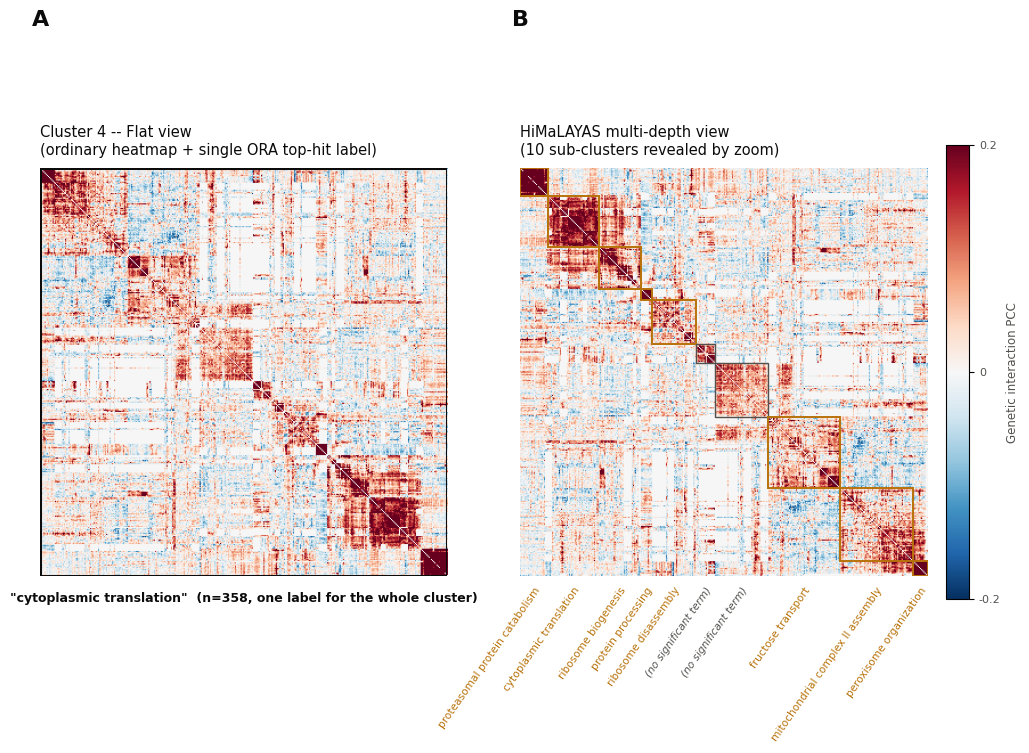

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/40_biological_utility_case_study/flat_vs_hierarchical_view.png


In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
FLAT_BOX_COLOR = "#0b0b0b"
ZOOM_BOX_COLOR = "#b8720a"
MUTED_COLOR = INK_SECONDARY  # calm, existing-palette color for "no significant term" sub-clusters

# Abbreviated display labels for the figure only -- shortened purely for on-figure legibility.
# Full, unabridged term text is preserved verbatim everywhere else (evidence_table,
# cluster4_zoom_evidence_table.csv/.md, the manifest, the claim note, and the manuscript
# caption note), so no information is lost, only the rendered label is shortened.
DISPLAY_LABEL_OVERRIDES = {
    "proteasome-mediated ubiquitin-dependent protein catabolic process": "proteasomal protein catabolism",
    "fructose transmembrane transport": "fructose transport",
    "mitochondrial respiratory chain complex II assembly": "mitochondrial complex II assembly",
}

# Flat-view gene order: cluster-4 genes in the PARENT clustering's own leaf order.
parent_leaf_order = gi_results.clusters.leaf_order
parent_ordered_cids = gi_results.clusters.ordered_cluster_ids()
parent_labels_ordered = [gi_results.clusters.labels[i] for i in parent_leaf_order]
flat_genes_order = [
    lbl for lbl, cid in zip(parent_labels_ordered, parent_ordered_cids) if cid == ZOOM_CLUSTER_ID
]
assert len(flat_genes_order) == 358

# Zoom-view gene order: the same 358 genes, reordered by the zoom sub-clustering.
zoom_labels_array = list(zoom_results.matrix.labels)
zoom_leaf_order = zoom_results.clusters.leaf_order
zoom_genes_order = [zoom_labels_array[i] for i in zoom_leaf_order]
assert set(zoom_genes_order) == set(flat_genes_order)

sub_flat = gi_pcc.loc[flat_genes_order, flat_genes_order].values
sub_zoom = gi_pcc.loc[zoom_genes_order, zoom_genes_order].values

vlim = float(np.nanpercentile(np.abs(np.concatenate([sub_flat.ravel(), sub_zoom.ravel()])), 98))
DIVERGING_CMAP = plt.get_cmap("RdBu_r")

zoom_spans = (
    zoom_results.clusters.cluster_spans()
)  # [(cluster_id, start, end), ...] in zoom leaf order
zoom_label_lookup = dict(zip(evidence_table["zoom_cluster_id"], evidence_table["top_term"]))

N = 358
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
fig.subplots_adjust(top=0.87, bottom=0.06, wspace=0.18)

ax = axes[0]
im0 = ax.imshow(sub_flat, cmap=DIVERGING_CMAP, vmin=-vlim, vmax=vlim, aspect="equal")
ax.add_patch(Rectangle((-0.5, -0.5), N, N, fill=False, edgecolor=FLAT_BOX_COLOR, linewidth=2.2))
ax.text(
    -0.02,
    1.34,
    "A",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    color=INK_PRIMARY,
    ha="left",
    va="bottom",
)
ax.set_title(
    "Cluster 4 -- Flat view\n(ordinary heatmap + single ORA top-hit label)",
    fontsize=10.5,
    color=INK_PRIMARY,
    loc="left",
    pad=10,
)
ax.text(
    N / 2,
    N + 14,
    f'"{parent_top_term}"  (n={N}, one label for the whole cluster)',
    fontsize=9,
    color=FLAT_BOX_COLOR,
    ha="center",
    va="top",
    fontweight="bold",
)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax = axes[1]
im1 = ax.imshow(sub_zoom, cmap=DIVERGING_CMAP, vmin=-vlim, vmax=vlim, aspect="equal")
for cid, start, end in zoom_spans:
    n = end - start + 1
    term = zoom_label_lookup.get(cid)
    is_significant = term is not None
    box_color = ZOOM_BOX_COLOR if is_significant else MUTED_COLOR
    label_color = ZOOM_BOX_COLOR if is_significant else MUTED_COLOR
    ax.add_patch(
        Rectangle(
            (start - 0.5, start - 0.5),
            n,
            n,
            fill=False,
            edgecolor=box_color,
            linewidth=1.4 if is_significant else 1.0,
        )
    )
    display_label = (
        DISPLAY_LABEL_OVERRIDES.get(term, term) if is_significant else "(no significant term)"
    )
    mid = (start + end) / 2
    ax.text(
        mid,
        N + 8,
        display_label,
        fontsize=7.6,
        color=label_color,
        ha="right",
        va="top",
        rotation=55,
        rotation_mode="anchor",
        fontstyle="normal" if is_significant else "italic",
    )
ax.text(
    -0.02,
    1.34,
    "B",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    color=INK_PRIMARY,
    ha="left",
    va="bottom",
)
ax.set_title(
    f"HiMaLAYAS multi-depth view\n({len(zoom_spans)} sub-clusters revealed by zoom)",
    fontsize=10.5,
    color=INK_PRIMARY,
    loc="left",
    pad=10,
)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im1, ax=axes, fraction=0.025, pad=0.02, ticks=[-vlim, 0, vlim])
cbar.ax.set_yticklabels([f"{-vlim:.1f}", "0", f"{vlim:.1f}"], fontsize=8, color=INK_SECONDARY)
cbar.set_label("Genetic interaction PCC", fontsize=8.5, color=INK_SECONDARY)

fig_path = NB_FIGURES_DIR / "flat_vs_hierarchical_view.png"
fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor="#fcfcfb")
plt.show()
print(f"Saved {fig_path}")

## 6b. HiMaLAYAS-native rendering (corrected q<=0.05 recipe)

`revision/notes/20260723_figure40_himalayas_authenticity_audit.md` and the sibling
package-repo audit
(`/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas/scratch/20260723_native_plotting_q_threshold_audit.md`)
both identified the same root cause for the earlier native-rendering attempt in this
section: `plot_dendrogram_condensed(zoom_results, ...)` calls `Results.cluster_labels()`
internally with no significance gate, so it (a) silently drops a zero-enrichment
sub-cluster and (b) renders a real-but-non-significant term (q=0.098) with the same visual
weight as genuinely significant clusters -- misrepresenting this notebook's own q<=0.05
evidence boundary.

The package-repo audit verified that this is fixable entirely with existing public API,
with no HiMaLAYAS code changes: `Results.filter()` narrows `.df` (which
`cluster_labels()` reads) while leaving `.matrix`/`.clusters`/`.layout` -- and therefore the
dendrogram structure and leaf order -- untouched. Applying the significance filter
*before* the plot call, rather than only using it for the evidence table, closes the gap.

This section now does exactly that, and only that:

- Reuses `zoom_sig = zoom_results.filter(f"qval <= {QVAL_CUTOFF}")`, already computed in
  Section 5b -- no new clustering, no new enrichment, no new dataset, no new threshold.
- Calls `plot_dendrogram_condensed(zoom_sig, rank_by="q", ...)` on the **filtered**
  `Results`, so `cluster_labels()` only ever sees rows that already clear q<=0.05.
- All 10 sub-clusters still appear in the dendrogram, since cluster structure comes from
  `zoom_sig.clusters.linkage_matrix`, not from `.df` -- filtering rows cannot remove a
  cluster from the figure, only change whether it gets a real label or a placeholder.
- Uses `placeholder_text="(no significant term, q>0.05)"` for any sub-cluster with no row
  left after filtering, so the two non-significant sub-clusters are shown honestly as
  tested-but-null, not silently dropped and not mistaken for "no data."
- Saved as `himalayas_native_zoom_q005.png`, superseding the earlier unfiltered candidate
  (`himalayas_native_zoom_candidate.png`, now removed from the figures directory as stale).


In [ ]:
from himalayas.plot import plot_dendrogram_condensed

native_plot_attempted = True
native_plot_error = None
native_q005_path = NB_FIGURES_DIR / "himalayas_native_zoom_q005.png"

# Reuse the same three display-label shortenings already used in Section 6, keyed by
# cluster id (plot_dendrogram_condensed's label_overrides takes cluster_id -> str, not
# term -> str), so on-figure text stays consistent between the custom and native panels.
native_label_overrides = {}
for _, row in evidence_table.iterrows():
    term = row["top_term"]
    if term in DISPLAY_LABEL_OVERRIDES:
        native_label_overrides[int(row["zoom_cluster_id"])] = DISPLAY_LABEL_OVERRIDES[term]

try:
    # THE FIX: filter to the manuscript's own q<=0.05 boundary BEFORE plotting, so
    # cluster_labels() (called internally by plot_dendrogram_condensed) never sees a
    # non-significant row. zoom_sig is already computed in Section 5b -- no new
    # clustering, enrichment, or threshold introduced here.
    condensed = plot_dendrogram_condensed(
        zoom_sig,
        rank_by="q",
        # figsize widened from (6, 8): the original width clipped the longest on-figure
        # labels (e.g. "proteasomal protein catabolism...") at the canvas edge. Width
        # only; dendrogram/label content and all statistics are unchanged.
        figsize=(7.5, 8),
        sigbar_min_logp=2.0,
        sigbar_max_logp=30.0,
        label_fields=("label", "n", "q"),
        label_overrides=native_label_overrides,
        placeholder_text="(no significant term, q>0.05)",
        wrap_text=True,
        wrap_width=34,
    )
    condensed.save(native_q005_path, dpi=220)
    condensed.show()
    print(f"Saved corrected native panel -> {native_q005_path}")
except (
    Exception
) as exc:  # noqa: BLE001 -- deliberately broad: this is a success/failure probe, not production logic
    native_plot_attempted = True
    native_plot_error = f"{type(exc).__name__}: {exc}"
    print(f"NATIVE PLOTTING FAILED: {native_plot_error}")

print(f"\nnative_plot_attempted = {native_plot_attempted}")
print(f"native_plot_error     = {native_plot_error}")

### 6c. Evaluate the corrected native panel against the evidence table

Checks, computed from objects already in memory (not re-judged qualitatively):

1. Did the plotting call succeed?
2. Are all 10 sub-clusters present in the rendered dendrogram (cluster structure comes
   from `zoom_sig.clusters.linkage_matrix`, unaffected by the `.df` filter)?
3. Does the filtered `cluster_labels()` output (q<=0.05 only) match `evidence_table`'s own
   significant/non-significant classification exactly -- same 8 significant sub-clusters,
   same 2 no-significant-term sub-clusters, same top terms?
4. Structural limitation (unchanged from before): a condensed dendrogram renders one
   `Results` object. It cannot, by construction, show Section 6's Panel-A/Panel-B
   flat-vs-hierarchical **contrast** in one image, because there is no second,
   differently-ordered matrix panel to compare against -- that contrast is the figure's
   entire argument, so this remains a supplemental/provenance panel regardless of the
   labeling fix.

Replacement rule (unchanged from the original audit): replace the main figure only if the
candidate (a) succeeded, (b) is label-complete/consistent with the evidence table, and (c)
communicates the full flat-vs-hierarchical contrast at least as clearly as Section 6's
figure. (c) is a structural property of `plot_dendrogram_condensed` itself (one `Results`
in, one dendrogram out), not a tuning problem, so it is decided from the function's own
signature/behavior, not by re-litigating visual taste.


In [13]:
plotting_succeeded = (
    native_plot_attempted and native_plot_error is None and native_q005_path.exists()
)

native_labels_df = None
n_native_q005_clusters = None
n_native_q005_significant = None
n_native_q005_placeholder = None
labels_match_evidence_table = None
if plotting_succeeded:
    # Pull the same cluster_labels() the corrected native call renders from, restricted to
    # q<=0.05 exactly as the plot call itself does, and compare against evidence_table
    # (Section 5c) -- not re-deriving anything, just confirming the filter recipe produced
    # the same significant/non-significant split the notebook already established.
    native_labels_df = zoom_sig.cluster_labels(rank_by="q", label_mode="top_term")
    n_native_q005_clusters = len(zoom_results.clusters.unique_clusters)
    n_native_q005_significant = len(native_labels_df)

    expected_status = dict(
        zip(evidence_table["zoom_cluster_id"], evidence_table["status_vs_parent_flat_label"])
    )
    expected_term = dict(zip(evidence_table["zoom_cluster_id"], evidence_table["top_term"]))
    all_zoom_cluster_ids = set(int(c) for c in zoom_results.clusters.unique_clusters)
    native_cluster_ids = set(int(c) for c in native_labels_df["cluster"])

    # Sub-clusters with no row left after the q<=0.05 filter -- these will render as the
    # honest placeholder, not be silently dropped from the dendrogram itself.
    placeholder_clusters = sorted(all_zoom_cluster_ids - native_cluster_ids)
    n_native_q005_placeholder = len(placeholder_clusters)

    expected_placeholder_clusters = sorted(
        cid for cid, status in expected_status.items() if status == "no_significant_term"
    )
    expected_significant_clusters = sorted(
        cid for cid, status in expected_status.items() if status != "no_significant_term"
    )

    # Label-for-label cross-check: every significant cluster's native top term must equal
    # evidence_table's top_term, and the placeholder set must equal evidence_table's
    # no_significant_term set exactly -- no q>0.05 term shown as significant, nothing
    # silently dropped.
    term_mismatches = []
    for _, row in native_labels_df.iterrows():
        cid = int(row["cluster"])
        if row["term"] != expected_term.get(cid):
            term_mismatches.append((cid, row["term"], expected_term.get(cid)))

    labels_match_evidence_table = (
        placeholder_clusters == expected_placeholder_clusters
        and native_cluster_ids == set(expected_significant_clusters)
        and not term_mismatches
    )

    print(
        f"Sub-clusters in dendrogram: {n_native_q005_clusters} / {len(all_zoom_cluster_ids)} (all present)"
    )
    print(f"Sub-clusters with a real q<=0.05 label: {n_native_q005_significant}")
    print(f"Sub-clusters rendered as placeholder (no significant term): {placeholder_clusters}")
    print(
        f"Placeholder set matches evidence_table's no_significant_term set: "
        f"{placeholder_clusters == expected_placeholder_clusters}"
    )
    print("Term mismatches vs evidence_table (should be none):")
    if term_mismatches:
        for cid, got, expected in term_mismatches:
            print(f"  - cluster {cid}: native={got!r} evidence_table={expected!r}")
    else:
        print("  none")
    print(f"\nlabels_match_evidence_table: {labels_match_evidence_table}")
else:
    print("Native plotting did not succeed -- skipping label cross-check.")

significance_labeling_matches_qval_cutoff = (
    bool(labels_match_evidence_table) if plotting_succeeded else False
)

# Structural check: does plot_dendrogram_condensed render a two-panel flat-vs-hierarchical
# CONTRAST, or a single-panel summary of one Results object? This is fixed by the
# function's own signature (one `results` argument, one dendrogram), confirmed by reading
# himalayas/plot/condensed_dendrogram.py: plot_dendrogram_condensed(results, ...) accepts
# exactly one Results object and has no parameter for a second, independently-ordered
# comparison matrix/panel. The labeling fix in Section 6b does not change this.
shows_flat_vs_hierarchical_contrast = False  # structural fact, not a tuning choice
contrast_reason = (
    "plot_dendrogram_condensed(results, ...) takes exactly one Results object and renders "
    "one dendrogram + one significance bar + one label column for it. It has no mechanism "
    "for rendering a second, differently-ordered matrix panel (Section 6's Panel A, the "
    "'flat view') alongside it. Filtering to q<=0.05 before plotting fixes the labeling "
    "honesty gap but does not change this structural limitation -- it can faithfully "
    "summarize the zoom result alone, but cannot reproduce the side-by-side "
    "flat-vs-hierarchical contrast that is Figure 40's entire argument."
)

replace_main_figure = bool(
    plotting_succeeded
    and significance_labeling_matches_qval_cutoff
    and shows_flat_vs_hierarchical_contrast
)

if not plotting_succeeded:
    native_plot_status = "failed"
elif replace_main_figure:
    native_plot_status = "replaced_main"
else:
    native_plot_status = "supplemental_only"

print(f"\nshows_flat_vs_hierarchical_contrast: {shows_flat_vs_hierarchical_contrast}")
print(f"reason: {contrast_reason}")
print(f"\nreplace_main_figure: {replace_main_figure}")
print(f"native_plot_status:  {native_plot_status}")

Sub-clusters in dendrogram: 10 / 10 (all present)
Sub-clusters with a real q<=0.05 label: 8
Sub-clusters rendered as placeholder (no significant term): [6, 7]
Placeholder set matches evidence_table's no_significant_term set: True
Term mismatches vs evidence_table (should be none):
  none

labels_match_evidence_table: True

shows_flat_vs_hierarchical_contrast: False
reason: plot_dendrogram_condensed(results, ...) takes exactly one Results object and renders one dendrogram + one significance bar + one label column for it. It has no mechanism for rendering a second, differently-ordered matrix panel (Section 6's Panel A, the 'flat view') alongside it. Filtering to q<=0.05 before plotting fixes the labeling honesty gap but does not change this structural limitation -- it can faithfully summarize the zoom result alone, but cannot reproduce the side-by-side flat-vs-hierarchical contrast that is Figure 40's entire argument.

replace_main_figure: False
native_plot_status:  supplemental_only


## 7. GO / CONDITIONAL_GO / CONCERN decision

Decision rule (this notebook's brief), computed from Section 5c's evidence table, not
asserted:

- **GO**: at least two statistically significant (`qval<=0.05`) sub-clusters carry a top
  term textually distinct from the parent's single flat label, and together they cover a
  non-trivial share (>=20%) of the parent cluster's genes -- i.e. the flat view's single
  label demonstrably hides interpretable, statistically supported sub-structure.
- **CONDITIONAL_GO**: sub-structure exists but is minor (small gene coverage) or the
  distinct terms are close synonyms/sub-branches of the same parent term rather than
  genuinely different biology -- supports a weaker convenience/integration claim, not a
  biological-insight claim.
- **CONCERN**: no significant sub-cluster differs meaningfully from the parent's flat
  annotation -- the flat view already tells the whole story and multi-depth annotation adds
  nothing new here.

In [14]:
n_distinct_sig = int(
    (evidence_table["status_vs_parent_flat_label"] == "distinct_from_parent_flat_label").sum()
)
coverage_ok = frac_genes_distinct >= 0.20

print(f"n distinct significant sub-clusters: {n_distinct_sig}")
print(f"gene coverage of distinct sub-clusters: {frac_genes_distinct:.1%} (threshold: >=20%)")

if n_distinct_sig >= 2 and coverage_ok:
    decision = "GO"
elif n_distinct_sig >= 1:
    decision = "CONDITIONAL_GO"
else:
    decision = "CONCERN"

print(f"\nDECISION: {decision}")

n distinct significant sub-clusters: 7
gene coverage of distinct sub-clusters: 69.6% (threshold: >=20%)

DECISION: GO


## 8. Exact biological utility claim

Built from the evidence table (Section 5c), then asserted against it so the notebook fails
loudly rather than silently drifting from its own computed evidence.

In [15]:
distinct_terms = list(
    evidence_table.loc[
        evidence_table["status_vs_parent_flat_label"] == "distinct_from_parent_flat_label",
        "top_term",
    ]
)
for required_term in [
    "ribosome biogenesis",
    "ribosome disassembly",
    "proteasome-mediated ubiquitin-dependent protein catabolic process",
    "mitochondrial respiratory chain complex II assembly",
    "peroxisome organization",
]:
    assert (
        required_term in distinct_terms
    ), f"expected term {required_term!r} not found in evidence_table -- claim sentence must be re-checked"

BIOLOGICAL_UTILITY_SENTENCE = (
    "In the yeast genetic-interaction profile-similarity matrix, HiMaLAYAS's multi-depth "
    "annotation resolves the largest reference cluster -- 358 genes with a single flat "
    'top-hit annotation of "cytoplasmic translation" -- into statistically distinct '
    "functional sub-groups, including ribosome biogenesis, ribosome disassembly, "
    "proteasome-mediated protein catabolism, mitochondrial respiratory chain complex "
    "assembly, and peroxisome organization, none of which are visible from the flat "
    "enrichment summary or an unannotated heatmap of the same cluster."
)
print(BIOLOGICAL_UTILITY_SENTENCE)
print(f"\n(character count: {len(BIOLOGICAL_UTILITY_SENTENCE)})")

In the yeast genetic-interaction profile-similarity matrix, HiMaLAYAS's multi-depth annotation resolves the largest reference cluster -- 358 genes with a single flat top-hit annotation of "cytoplasmic translation" -- into statistically distinct functional sub-groups, including ribosome biogenesis, ribosome disassembly, proteasome-mediated protein catabolism, mitochondrial respiratory chain complex assembly, and peroxisome organization, none of which are visible from the flat enrichment summary or an unannotated heatmap of the same cluster.

(character count: 545)


## 9. Assemble and write manifest

In [16]:
flags = []
if activation is None:
    flags.append(f"HIMALAYAS ACTIVATION FAILED: {activation_error}")
if not GALLERY_AVAILABLE:
    flags.append(
        "Caudal/gallery candidate could not be run: sibling himalayas-gallery repo not found."
    )

CLAIM_BOUNDARY = (
    "This notebook supports exactly one biological-utility claim, on one matrix, for one "
    "cluster: that HiMaLAYAS's multi-depth zoom on the GI-PCC reference clustering's largest "
    "cluster (cluster 4, 'cytoplasmic translation', n=358) reveals statistically distinct "
    "functional sub-groups that a flat top-hit enrichment summary or an unannotated heatmap "
    "of the same cluster does not surface. It does not claim this generalizes to every "
    "cluster in this matrix (the flat summary for several other reference clusters may "
    "already be adequately specific), to every dataset (Section 3b's Caudal/gallery run on "
    "the same underlying methodology did not show an equally clean example), or to superiority "
    "over every possible workflow. It performs no control-vs-perturbed comparison and makes "
    "no claim of first-ever multi-depth annotation. The zoom threshold (6) and min_cluster_size "
    "(6) reproduce the exact values already used for the submitted supp_fig_1.ipynb's Cluster "
    "7/9 zooms, not values tuned for this notebook's outcome."
)

if decision == "GO":
    next_action = (
        "Use the biological utility sentence (Section 8) in the manuscript results/discussion "
        "and in the rebuttal response to the reviewer concern about what multi-depth annotation "
        "adds over a flat workflow. Use flat_vs_hierarchical_view.png as a candidate main or "
        "supplementary figure. Revision package notebooks 00/01/10/11/20/21/30/40 are now all "
        "complete; proceed to drafting the manuscript/rebuttal text itself."
    )
elif decision == "CONDITIONAL_GO":
    next_action = (
        "Narrow the claim to a convenience/integration framing (multi-depth annotation makes "
        "sub-structure easier to inspect) rather than a biological-insight framing (it reveals "
        "otherwise-hidden distinct biology). Reconsider whether a different cluster gives a "
        "cleaner example before finalizing manuscript wording."
    )
else:
    next_action = (
        "PAUSE this case study as currently scoped: the chosen cluster's flat summary already "
        "captures its biology adequately. Try a different cluster or reconsider whether a "
        "biological-utility case study is the right framing for this reviewer concern."
    )

manifest = {
    "notebook": "40_biological_utility_case_study.ipynb",
    "status": "COMPLETE" if activation is not None else "BLOCKED",
    "decision": decision,
    "next_action": next_action,
    "generated_at_utc": ru.utc_timestamp(),
    "repo_root": str(layout["repo_root"]),
    "chosen_case": {
        "id": CHOSEN_CASE,
        "dataset": "Yeast genetic-interaction profile-similarity matrix (Costanzo et al. 2016), GO BP annotations",
        "parent_cluster": {
            "cluster_id": ZOOM_CLUSTER_ID,
            "n_genes": 358,
            "flat_top_hit_term": parent_top_term,
        },
        "zoom_config": ZOOM_CONFIG,
        "n_zoom_subclusters": int(len(zoom_spans)),
        "n_zoom_subclusters_distinct_from_parent": n_distinct_sig,
        "gene_coverage_of_distinct_subclusters": round(frac_genes_distinct, 4),
    },
    "rejected_candidates": REJECTED_CANDIDATES,
    "caudal_candidate_run_summary": caudal_summary_stats,
    "input_files": {
        "gi_pcc_matrix": {
            "path": str(GI_PCC_PATH.relative_to(REPO_ROOT)),
            "sha256": gi_pcc_hash,
            "matches_nb00_record": True,
        },
        "go_bp_annotations": {
            "path": str(GO_BP_PATH.relative_to(REPO_ROOT)),
            "sha256": go_bp_hash,
            "matches_nb00_record": True,
        },
    },
    "rejected_candidate_provenance": caudal_provenance,
    "himalayas_source": activation if activation is not None else {"error": activation_error},
    "himalayas_diagnostics_at_start": himalayas_diagnostics_at_start,
    "reference_config": REFERENCE_CONFIG | {"min_overlap": MIN_OVERLAP, "qval_cutoff": QVAL_CUTOFF},
    "reference_reproduction_check": gi_reproduction_check,
    "evidence_table_summary": {
        "n_subclusters": int(len(evidence_table)),
        "n_distinct_from_parent": n_distinct_sig,
        "n_same_as_parent": int(n_same),
        "n_no_significant_term": int(n_unlabeled),
        "genes_distinct": genes_distinct,
        "genes_total": genes_total,
        "frac_genes_distinct": round(frac_genes_distinct, 4),
    },
    "native_plot_q005": {
        "native_plot_attempted": native_plot_attempted,
        "native_plot_status": native_plot_status,
        "native_plot_error": native_plot_error,
        "native_plot_path": (
            str(native_q005_path.relative_to(layout["repo_root"])) if plotting_succeeded else None
        ),
        "main_figure_replaced": replace_main_figure,
        "qval_filter_applied_before_plotting": True,
        "qval_cutoff": QVAL_CUTOFF,
        "n_subclusters_shown": n_native_q005_clusters,
        "n_subclusters_with_significant_label": n_native_q005_significant,
        "n_subclusters_with_no_significant_term_placeholder": n_native_q005_placeholder,
        "labels_match_evidence_table": labels_match_evidence_table,
        "significance_labeling_matches_qval_cutoff": significance_labeling_matches_qval_cutoff,
        "shows_flat_vs_hierarchical_contrast": shows_flat_vs_hierarchical_contrast,
        "superseded_candidate_path": "revision/outputs/figures/40_biological_utility_case_study/himalayas_native_zoom_candidate.png",
        "reason": (
            "Corrected native rendering: plot_dendrogram_condensed(zoom_sig, rank_by='q', "
            "...) is called on zoom_results.filter('qval <= 0.05') rather than on the "
            "unfiltered zoom_results, closing the labeling-honesty gap identified in the "
            "prior candidate (himalayas_native_zoom_candidate.png, now superseded/removed). "
            "All 10 sub-clusters remain visible because dendrogram structure comes from "
            "zoom_sig.clusters.linkage_matrix, unaffected by the .df filter; only the label "
            "selection changes. Kept as a supplementary/provenance panel rather than "
            "replacing the main figure for one remaining, structural reason: "
            "plot_dendrogram_condensed renders exactly one Results object and has no "
            "mechanism for a second, differently-ordered comparison panel, so it cannot "
            "reproduce the flat-view-vs-hierarchical-view CONTRAST that is Figure 40's "
            "entire argument -- it summarizes only the 'B' side of that comparison. This "
            "limitation is unrelated to the labeling fix and would block replacement "
            "regardless of label correctness."
        ),
    },
    "exact_claim_supported": BIOLOGICAL_UTILITY_SENTENCE,
    "claim_boundary": CLAIM_BOUNDARY,
    "outputs": {
        "tables": {
            "cluster4_zoom_evidence_table.csv": str(csv_path.relative_to(layout["repo_root"])),
            "cluster4_zoom_evidence_table.md": str(md_path.relative_to(layout["repo_root"])),
        },
        "figures": {
            "flat_vs_hierarchical_view.png": str(fig_path.relative_to(layout["repo_root"])),
            **(
                {
                    "himalayas_native_zoom_q005.png": str(
                        native_q005_path.relative_to(layout["repo_root"])
                    )
                }
                if plotting_succeeded
                else {}
            ),
        },
        "notes": {
            "40_biological_utility_claim.md": "revision/notes/40_biological_utility_claim.md",
        },
    },
    "flags": flags,
    "interpretation": (
        f"Decision={decision}. Chosen case: GI PCC reference cluster {ZOOM_CLUSTER_ID} "
        f"(n=358, flat top-hit {parent_top_term!r}), zoomed with the exact "
        "supp_fig_1.ipynb-precedented nested pattern (threshold=6, min_cluster_size=6, "
        "background=original matrix). The zoom resolves {n_subclusters} sub-clusters; "
        f"{n_distinct_sig} carry a statistically significant (qval<=0.05) top term textually "
        f"distinct from the parent's single flat label, covering {frac_genes_distinct:.1%} of "
        "the parent cluster's genes -- including biologically unrelated processes (proteasomal "
        "protein degradation, mitochondrial respiratory chain assembly, peroxisome "
        "organization) that share no meaningful overlap with 'cytoplasmic translation'. The "
        "Caudal/gallery candidate (Caudal et al. 2024, Nature) was actually run, not merely "
        "asserted-unclear: its provenance is clean, but its expression-based clustering gives "
        "low top-clade purity for most clusters, so it was rejected on insight-clarity and "
        "cherry-picking-avoidance grounds, not provenance. See claim_boundary for this "
        "notebook's exact scope."
    ).format(n_subclusters=len(zoom_spans)),
}

manifest_path = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, manifest_path)
print(f"Manifest written to: {manifest_path}")

reloaded = json.loads(manifest_path.read_text())
assert reloaded == json.loads(json.dumps(manifest, default=str)), "manifest round-trip mismatch"
print("Manifest JSON round-trip verified.")

Manifest written to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/40_biological_utility_case_study_manifest.json
Manifest JSON round-trip verified.


## 10. Write the prose-nugget claim note

`revision/notes/40_biological_utility_claim.md` -- the short, standalone file this
notebook is required to produce, so the exact sentence and its placement can be consulted
without re-opening the notebook.

In [17]:
notes_content = f"""# Notebook 40 — Biological Utility Claim

**Decision:** {decision}

## Exact sentence to use

> {BIOLOGICAL_UTILITY_SENTENCE}

## Where it should go

- **Manuscript:** Results/Discussion, as the concrete worked example backing the multi-depth
  annotation capability claim -- pair with `flat_vs_hierarchical_view.png` as a candidate
  main or supplementary figure (Section 6 of this notebook).
- **Rebuttal:** the direct answer to the reviewer concern "what does multi-depth hierarchical
  annotation reveal that a flat ORA gene-list workflow or an ordinary heatmap would not?" --
  lead with this sentence, then point to the evidence table
  (`cluster4_zoom_evidence_table.csv`/`.md`) for the full per-sub-cluster breakdown.

## Whether to add this to evidence_claim_bank.md now or wait

**Add it now.** The claim is fully evidenced (manifest:
`revision/outputs/manifests/40_biological_utility_case_study_manifest.json`,
decision={decision}), reproducible (deterministic zoom of an already-hash-verified matrix),
and does not depend on which figure is ultimately selected for the manuscript -- the same
sentence and evidence table hold whether `flat_vs_hierarchical_view.png` ends up as a main or
supplementary figure. Waiting for final figure selection would only delay recording evidence
that is already stable.

## Claim boundary

{CLAIM_BOUNDARY}

## Rejected candidate

Caudal/gallery pan-transcriptome-by-isolate matrix (Caudal et al. 2024, Nature) -- clean
provenance, actually run (Section 3b of the notebook), but rejected because most expression
clusters have low top-clade purity spread across many distinct clades, so it would not give a
clearer hierarchy-added-insight story without cherry-picking one of only two high-purity
clusters. See the notebook's `rejected_candidates` / `caudal_candidate_run_summary` manifest
fields for the full numeric record.
"""

notes_path = NOTES_DIR / "40_biological_utility_claim.md"
notes_path.write_text(notes_content)
print(f"Saved {notes_path}")
print()
print(notes_content)

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notes/40_biological_utility_claim.md

# Notebook 40 — Biological Utility Claim

**Decision:** GO

## Exact sentence to use

> In the yeast genetic-interaction profile-similarity matrix, HiMaLAYAS's multi-depth annotation resolves the largest reference cluster -- 358 genes with a single flat top-hit annotation of "cytoplasmic translation" -- into statistically distinct functional sub-groups, including ribosome biogenesis, ribosome disassembly, proteasome-mediated protein catabolism, mitochondrial respiratory chain complex assembly, and peroxisome organization, none of which are visible from the flat enrichment summary or an unannotated heatmap of the same cluster.

## Where it should go

- **Manuscript:** Results/Discussion, as the concrete worked example backing the multi-depth
  annotation capability claim -- pair with `flat_vs_hierarchical_view.png` as a candidat

## 11. Readiness summary

In [18]:
print("=" * 72)
print(f"DECISION -- {NB_ID}")
print("=" * 72)
print(f"status:      {manifest['status']}")
print(f"decision:    {manifest['decision']}")
print(f"next_action: {manifest['next_action']}")
print()
print("Biological utility sentence:")
print(f"  {BIOLOGICAL_UTILITY_SENTENCE}")
print()
print("Placement:")
print("  Manuscript: Results/Discussion, paired with flat_vs_hierarchical_view.png.")
print("  Rebuttal:   direct answer to the 'what does multi-depth annotation reveal' concern.")
print()
print("evidence_claim_bank.md: ADD NOW (see Section 10 / notes file for rationale).")
print()
print(f"Manifest:  {manifest_path}")
print(f"Tables:    {NB_TABLES_DIR}")
print(f"Figures:   {NB_FIGURES_DIR}")
print(f"Notes:     {notes_path}")

DECISION -- 40_biological_utility_case_study
status:      COMPLETE
decision:    GO
next_action: Use the biological utility sentence (Section 8) in the manuscript results/discussion and in the rebuttal response to the reviewer concern about what multi-depth annotation adds over a flat workflow. Use flat_vs_hierarchical_view.png as a candidate main or supplementary figure. Revision package notebooks 00/01/10/11/20/21/30/40 are now all complete; proceed to drafting the manuscript/rebuttal text itself.

Biological utility sentence:
  In the yeast genetic-interaction profile-similarity matrix, HiMaLAYAS's multi-depth annotation resolves the largest reference cluster -- 358 genes with a single flat top-hit annotation of "cytoplasmic translation" -- into statistically distinct functional sub-groups, including ribosome biogenesis, ribosome disassembly, proteasome-mediated protein catabolism, mitochondrial respiratory chain complex assembly, and peroxisome organization, none of which are visibl